# Alberta Electricity Price - Exploratory Data Analysis

**Objective:** Understand the data before building the ML model.
**Key question:** Can we beat the AESO forecast on price spikes?

## Sections
- Section 0 — Load data
- Section 1 — Quick inspection
- Section 2 — Univariate analysis (price, demand, error)
- Section 3 — Bivariate analysis (relationships between variables)
- Section 4 — Data cleaning (based on what we found)
- Section 5 — Data ready for ML

In [44]:
# 📦 Core libraries
import psycopg2,os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# 🎨 Plot style — clean and readable
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# 🔑 Load credentials
load_dotenv()

print("✅ Libraries loaded")

✅ Libraries loaded


## Section 0 - Load Data

We load directly from PostgreSQL - single source of truth.
Both CSV historical data and API real-time data are in the same table.

In [45]:
# 🔌 Connect to PostgreSQL
conn = psycopg2.connect(
  host=os.getenv("DB_HOST"),
  port=os.getenv("DB_PORT"),
  dbname=os.getenv("DB_NAME"),
  user=os.getenv("DB_USER"),
  password=os.getenv("DB_PASSWORD"),
)

# 📥 Load all data — ordered by time
query = """
  SELECT *
  FROM pool_prices
  ORDER BY timestamp_utc ASC;
"""

df = pd.read_sql(query, conn)
conn.close()

# 📅 Set timestamp as index
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
df = df.set_index("timestamp_utc")

print(f"✅ Loaded {len(df):,} rows")
print(f"📅 From : {df.index.min()}")
print(f"📅 To   : {df.index.max()}")

/var/folders/hj/lqfwhhdj3cv7hysytn8j6nf80000gn/T/ipykernel_83201/1349218679.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ Loaded 54,565 rows
📅 From : 2020-01-01 07:00:00+00:00
📅 To   : 2026-03-23 19:00:00+00:00


## Section 1 - Quick Inspection

Before any visualization — understand what we have.
- Shape : how many rows and columns ?
- Types : are the columns the right type ?
- NULLs : where are the missing values ?
- Stats : what are the basic statistics ?

In [46]:
# 📐 Shape
print(f"📐 Shape : {df.shape}")
print(f"\n📋 Columns and types :")
print(df.dtypes)

📐 Shape : (54565, 12)

📋 Columns and types :
price_actual            float64
price_forecast          float64
consumption_actual      float64
consumption_forecast    float64
total_generation_mw     float64
export_to_bc            float64
export_to_mt            float64
export_to_sk            float64
import_from_bc          float64
import_from_mt          float64
import_from_sk          float64
source                      str
dtype: object


In [47]:
# ❓ Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

summary = pd.DataFrame({
  "missing_count" : missing,
  "missing_pct"   : missing_pct,
}).sort_values("missing_pct", ascending=False)

print("❓ Missing values :")
print(summary[summary["missing_count"] > 0])


❓ Missing values :
                      missing_count  missing_pct
consumption_forecast          48935         89.7
total_generation_mw            5630         10.3
export_to_bc                   5630         10.3
export_to_mt                   5630         10.3
export_to_sk                   5630         10.3
import_from_bc                 5630         10.3
import_from_mt                 5630         10.3
import_from_sk                 5630         10.3
price_actual                      3          0.0
consumption_actual                3          0.0


In [48]:
# 📊 Basic statistics — only numeric columns
print("📊 Basic statistics :")
df[["price_actual", "price_forecast", "consumption_actual",
    "consumption_forecast", "total_generation_mw"]].describe().round(2)

📊 Basic statistics :


,price_actual,price_forecast,consumption_actual,consumption_forecast,total_generation_mw
count,54562.00,54565.00,54562.00,5630.00,48935.00
mean,89.62,95.24,9930.92,10661.73,7078.10
std,150.68,165.79,859.13,771.26,844.01
min,0.00,0.00,7579.00,8824.00,4512.17
25%,28.71,28.53,9316.00,10139.25,6483.84
50%,42.25,42.01,9918.00,10665.00,7053.98
75%,74.68,73.69,10551.00,11206.75,7630.69
max,999.99,999.99,12785.00,12688.00,10241.69


In [49]:
# 🔍 Investigate NULL prices
print("🔍 Rows with NULL price_actual :")
print(df[df["price_actual"].isnull()][["price_actual", "price_forecast", "consumption_actual", "source"]])

# 🔍 Investigate 999.99 sentinel values
print(f"\n🔍 Rows with price_actual = 999.99 : {(df['price_actual'] == 999.99).sum()}")
print(f"🔍 Rows with price_forecast = 999.99 : {(df['price_forecast'] == 999.99).sum()}")
print(df[df["price_actual"] == 999.99][["price_actual", "price_forecast", "consumption_actual", "source"]].head(5))

🔍 Rows with NULL price_actual :
                           price_actual  price_forecast  consumption_actual  \
timestamp_utc                                                                 
2026-03-23 17:00:00+00:00           NaN           18.59                 NaN   
2026-03-23 18:00:00+00:00           NaN           17.01                 NaN   
2026-03-23 19:00:00+00:00           NaN           16.88                 NaN   

                          source  
timestamp_utc                     
2026-03-23 17:00:00+00:00    api  
2026-03-23 18:00:00+00:00    api  
2026-03-23 19:00:00+00:00    api  

🔍 Rows with price_actual = 999.99 : 82
🔍 Rows with price_forecast = 999.99 : 91
                           price_actual  price_forecast  consumption_actual  \
timestamp_utc                                                                 
2020-01-14 01:00:00+00:00        999.99          995.38             11609.0   
2020-01-14 02:00:00+00:00        999.99          999.99             11447.0   


## Section 1 — Findings

| Issue | Count | Action |
|-------|-------|--------|
| NULL price - future hours not yet known | 3 | Drop for training |
| price = 999.99 - Alberta legal market cap | 82 | Keep - real spikes |
| consumption_forecast NULL - API only | 89.7% | Expected |
| export/import NULL - CSV only | 10.3% | Expected |

In [50]:
# 🧹 Drop future hours - price not yet known
df_clean = df[df["price_actual"].notnull()].copy()

print(f"📐 Before : {len(df):,} rows")
print(f"📐 After  : {len(df_clean):,} rows")
print(f"🗑️  Dropped : {len(df) - len(df_clean):,} future rows")


📐 Before : 54,565 rows
📐 After  : 54,562 rows
🗑️  Dropped : 3 future rows


## Section 2 — Univariate Analysis

Goal: understand the distribution and behaviour of each key variable.

Questions:
1. How is the price distributed ?
2. Are there extreme spikes ?
3. How does price evolve over time ?
4. Are there patterns by hour of day ?
5. Are there patterns by month ?
6. What is the distribution of the AESO forecast error ?
7. At which hours does the AESO make the biggest mistakes ?
8. Is April 5, 2024 visible as an anomaly ?

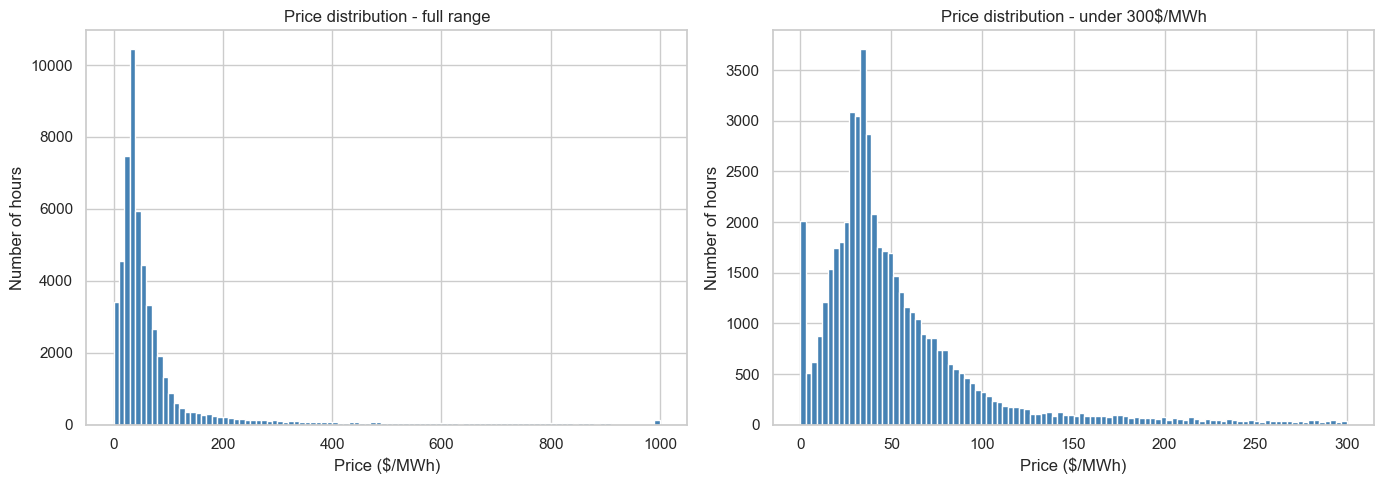

📊 % of hours above 300$/MWh : 6.6%
📊 % of hours above 100$/MWh : 16.6%
📊 % of hours at market cap (999.99) : 0.15%


In [51]:
# 📊 Q1 — How is the price distributed ?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean["price_actual"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Price distribution - full range")
axes[0].set_xlabel("Price ($/MWh)")
axes[0].set_ylabel("Number of hours")

# Histogram — zoomed under 300$/MWh
axes[1].hist(df_clean[df_clean["price_actual"] < 300]["price_actual"],bins=100, color="steelblue", edgecolor="white")
axes[1].set_title("Price distribution - under 300$/MWh")
axes[1].set_xlabel("Price ($/MWh)")
axes[1].set_ylabel("Number of hours")

plt.tight_layout()
plt.show()


print(f"📊 % of hours above 300$/MWh : {(df_clean['price_actual'] > 300).mean() * 100:.1f}%")
print(f"📊 % of hours above 100$/MWh : {(df_clean['price_actual'] > 100).mean() * 100:.1f}%")
print(f"📊 % of hours at market cap (999.99) : {(df_clean['price_actual'] == 999.99).mean() * 100:.2f}%")

### Finding - Price distribution

The price is highly right-skewed.
Most hours (83%) are cheap - between 0 and 100$/MWh.
But 6.6% of hours spike above 300$/MWh - these are the hours that destroy budgets.
The market cap (999.99$/MWh) is hit 0.15% of the time - rare but catastrophic.

This asymmetry is the core challenge : our model must perform well on rare events.

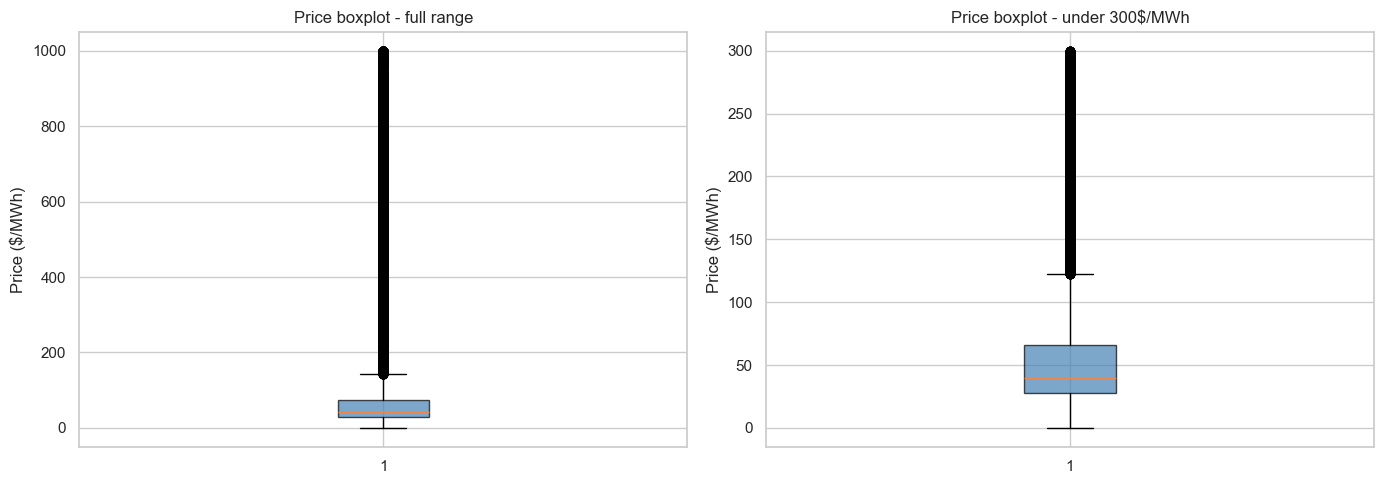

  50th percentile : 42.25 $/MWh
  75th percentile : 74.68 $/MWh
  90th percentile : 182.53 $/MWh
  95th percentile : 403.14 $/MWh
  99th percentile : 837.52 $/MWh
  99.9th percentile : 999.99 $/MWh


In [52]:
# 📊 Q2 — Are there extreme spikes ?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot — full range
axes[0].boxplot(df_clean["price_actual"].dropna(), vert=True, patch_artist=True,
  boxprops=dict(facecolor="steelblue", alpha=0.7))

axes[0].set_title("Price boxplot - full range")
axes[0].set_ylabel("Price ($/MWh)")

# Boxplot — zoomed under 300$/MWh
axes[1].boxplot(df_clean[df_clean["price_actual"] < 300]["price_actual"].dropna(),
  vert=True, patch_artist=True,
  boxprops=dict(facecolor="steelblue", alpha=0.7))

axes[1].set_title("Price boxplot - under 300$/MWh")
axes[1].set_ylabel("Price ($/MWh)")

plt.tight_layout()
plt.show()

# 📊 Percentiles
percentiles = [50, 75, 90, 95, 99, 99.9]
for p in percentiles:
  val = df_clean["price_actual"].quantile(p/100)
  print(f"  {p}th percentile : {val:.2f} $/MWh")

### Finding - Price spikes

The price is extremely volatile above the 90th percentile.
- 50% of hours : below 42$/MWh - normal market
- 90% of hours : below 182$/MWh - elevated but manageable
- 95% of hours : below 403$/MWh - major spike
- 99% of hours : below 837$/MWh - crisis level

The top 10% of hours represent the biggest risk for Alberta families.
Our model must focus on predicting these hours correctly.

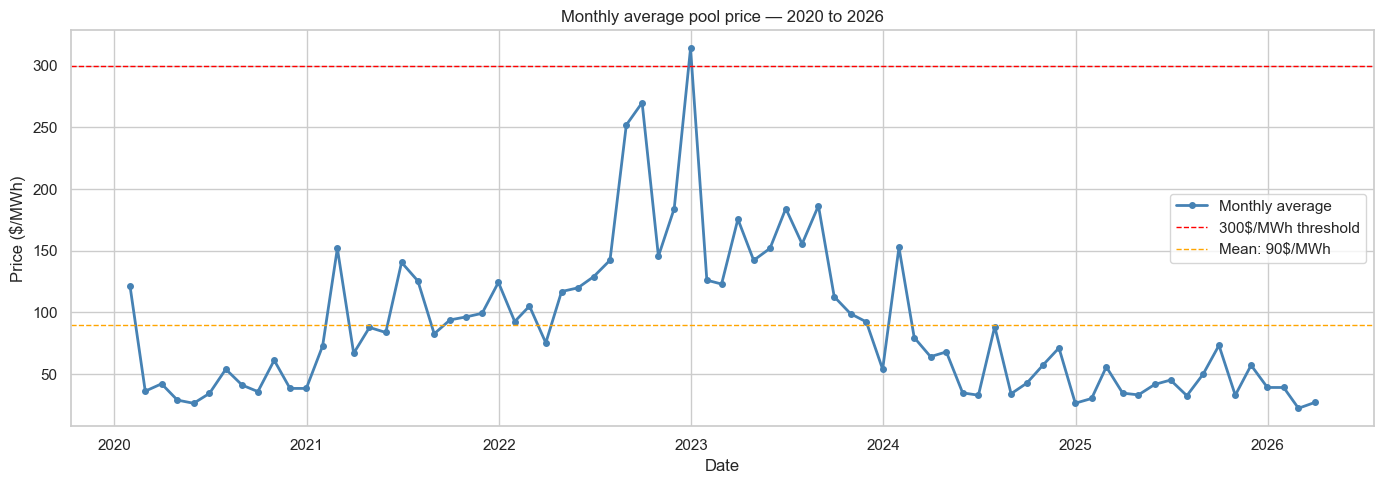

In [54]:
# 📊 Q3 — How does price evolve over time ?
fig, ax = plt.subplots(figsize=(14, 5))

# 📈 Monthly average — smooth and readable
monthly_avg = df_clean["price_actual"].resample("ME").mean()

ax.plot(monthly_avg, color="steelblue", linewidth=2, marker="o", markersize=4, label="Monthly average")
ax.axhline(y=300, color="red", linestyle="--", linewidth=1, label="300$/MWh threshold")
ax.axhline(y=df_clean["price_actual"].mean(), color="orange",
           linestyle="--", linewidth=1, label=f"Mean: {df_clean['price_actual'].mean():.0f}$/MWh")

ax.set_title("Monthly average pool price — 2020 to 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($/MWh)")
ax.legend()

plt.tight_layout()
plt.show()

### Finding — Price over time

- 2022-2023 was the crisis period - monthly average hit 310$/MWh in January 2023.
  This matches the 600,000 Albertans who received unexpectedly high bills.
- 2025 was the calmest year - market consistently below the mean.
- Spikes are not random - they build over months then collapse.
  This multi-month structure is useful signal for our ML model.

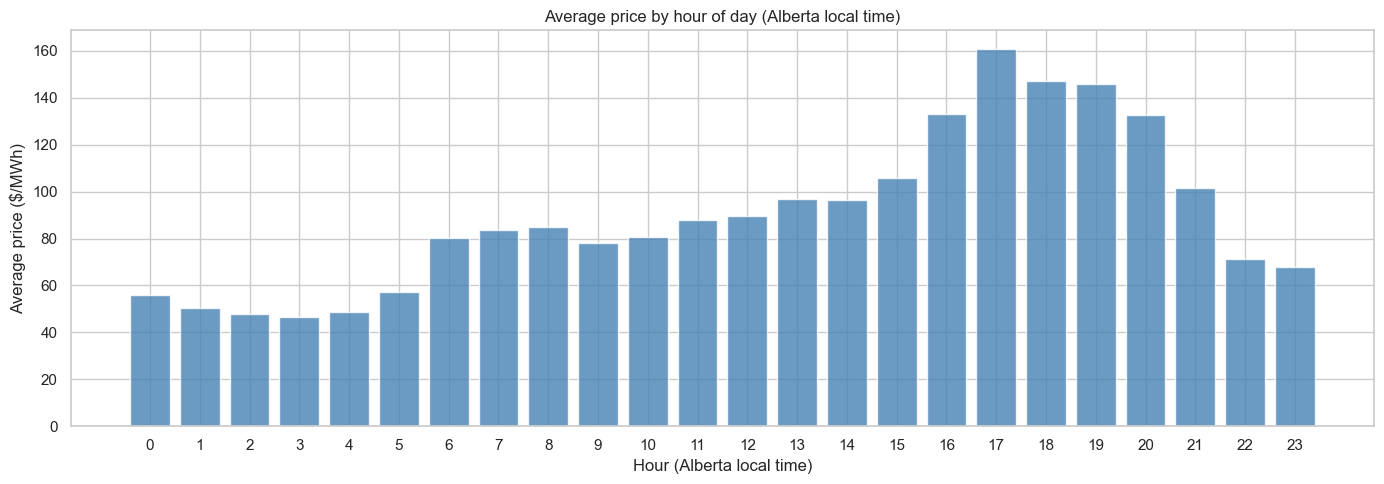

🔍 Top 3 most expensive hours (local time) :
hour_local
17    160.739644
18    147.231117
19    145.875134
Name: price_actual, dtype: float64

🔍 Top 3 cheapest hours (local time) :
hour_local
3    46.545642
2    47.641557
4    48.504529
Name: price_actual, dtype: float64


In [59]:
# 📊 Q4 — Patterns by hour of day — in local Alberta time
df_clean["hour_local"] = df_clean.index.tz_convert("America/Edmonton").hour

fig, ax = plt.subplots(figsize=(14, 5))

hourly_avg = df_clean.groupby("hour_local")["price_actual"].mean()
hourly_std = df_clean.groupby("hour_local")["price_actual"].std()

ax.bar(hourly_avg.index, hourly_avg.values, color="steelblue", alpha=0.8)
ax.set_title("Average price by hour of day (Alberta local time)")
ax.set_xlabel("Hour (Alberta local time)")
ax.set_ylabel("Average price ($/MWh)")
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print("🔍 Top 3 most expensive hours (local time) :")
print(hourly_avg.nlargest(3))
print("\n🔍 Top 3 cheapest hours (local time) :")
print(hourly_avg.nsmallest(3))

### Finding - Hourly patterns

Clear daily pattern in Alberta local time :
- Cheapest hours  : 2h → 5h (night) — avg ~45$/MWh
- Morning ramp-up : 6h → 9h
- Evening peak    : 16h → 20h — avg ~130-160$/MWh — 3x more expensive than night

Actionable insight for families :
→ Run appliances before 9h or after 21h to minimize electricity costs.

Key ML insight :
→ Hour of day is a strong predictor of price level.
   It must be included as a feature in our model.

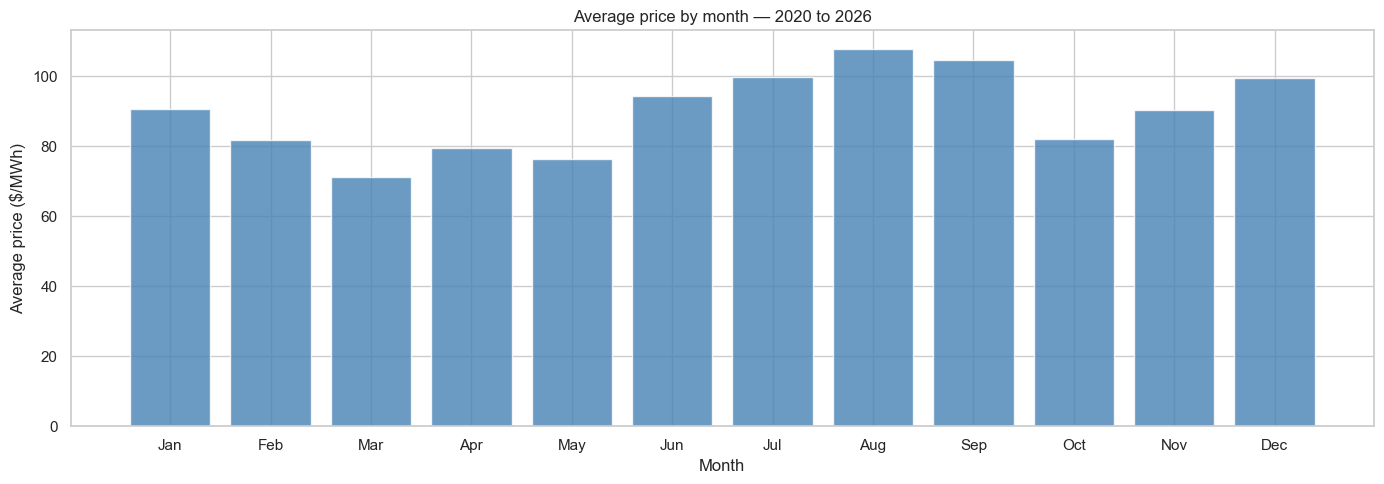

🔍 Most expensive months :
month
8    107.742619
9    104.792111
7     99.762923
Name: price_actual, dtype: float64

🔍 Cheapest months :
month
3    71.113705
5    76.443777
4    79.564863
Name: price_actual, dtype: float64


In [65]:
# 📊 Q5 — Are there patterns by month ?
fig, ax = plt.subplots(figsize=(14, 5))

df_clean["month"] = df_clean.index.month
monthly_pattern = df_clean.groupby("month")["price_actual"].mean()


months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

ax.bar(range(1, 13), monthly_pattern.values, color="steelblue", alpha=0.8)
ax.set_title("Average price by month — 2020 to 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Average price ($/MWh)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)

plt.tight_layout()
plt.show()

print("🔍 Most expensive months :")
print(monthly_pattern.nlargest(3))
print("\n🔍 Cheapest months :")
print(monthly_pattern.nsmallest(3))


### Finding — Monthly patterns

Two seasonal peaks :
- Summer (Aug-Sep) : highest average price — air conditioning demand
- Winter (Dec-Jan) : second peak — heating demand
- Spring (Mar-May) : cheapest months — mild weather, low demand

Surprise : summer is MORE expensive than winter on average.
But winter produces the most catastrophic spikes (2022-2023 crisis).

Key ML insight :
→ Month of year is a useful feature — captures seasonal demand patterns.

In [79]:
# 📊 Calculate AESO forecast error
# error > 0 → AESO underestimated (spike they missed)
# error < 0 → AESO overestimated (spike that didn't happen)
df_clean["forecast_error"] = df_clean["price_actual"] - df_clean["price_forecast"]

print("📊 AESO forecast error statistics :")
print(df_clean["forecast_error"].describe().round(2))



print(f"\n📊 Mean absolute error (MAE) : {df_clean['forecast_error'].abs().mean():.2f} $/MWh")
print(f"📊 % of hours AESO underestimated : {(df_clean['forecast_error'] > 0).mean() * 100:.1f}%")
print(f"📊 % of hours AESO overestimated  : {(df_clean['forecast_error'] < 0).mean() * 100:.1f}%")

📊 AESO forecast error statistics :
count    54562.00
mean        -5.62
std         70.57
min       -894.29
25%         -2.60
50%          0.00
75%          2.39
max        831.40
Name: forecast_error, dtype: float64

📊 Mean absolute error (MAE) : 22.64 $/MWh
📊 % of hours AESO underestimated : 46.8%
📊 % of hours AESO overestimated  : 48.8%


### Finding - AESO forecast error

- MAE = 22.64 $/MWh — this is our baseline to beat
- Median error = 0 — AESO is often perfect on normal hours
- Max underestimate = +831$/MWh - they completely missed a massive spike
- Max overestimate  = -894$/MWh - they predicted a spike that never happened

The AESO is good at normal hours but fails on extreme events.
Our model must focus on these extreme cases.

Baseline to beat : MAE < 22.64 $/MWh

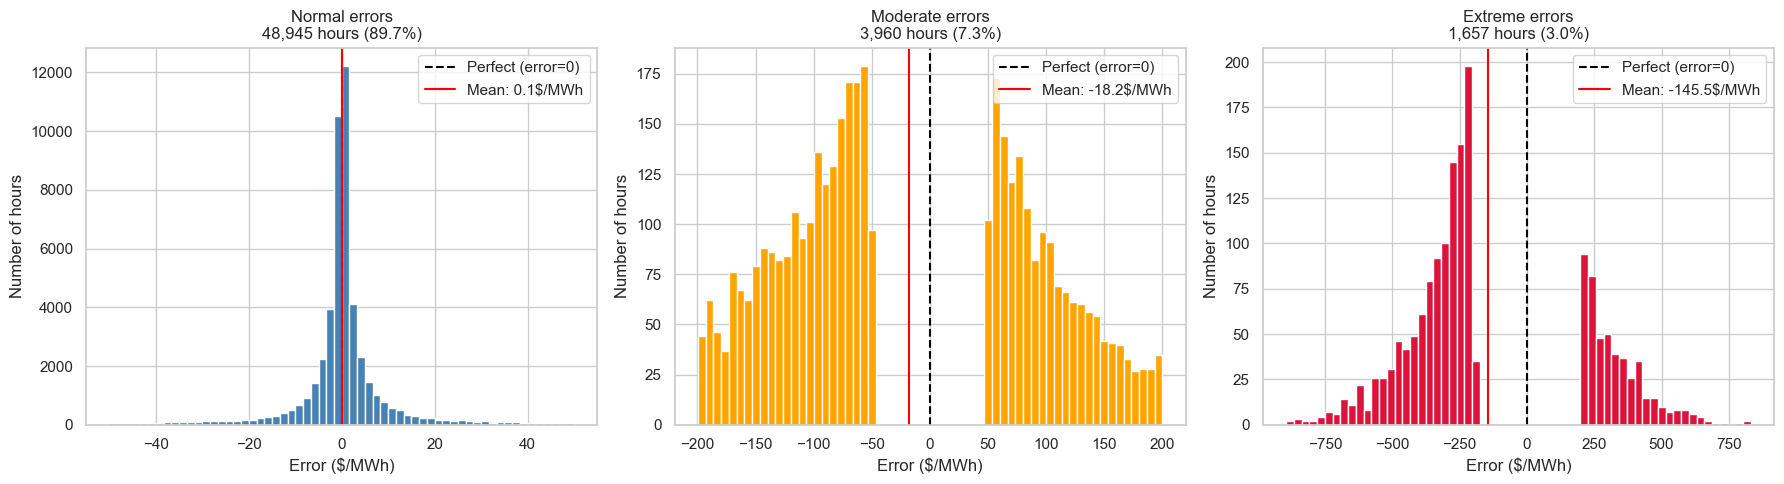

In [80]:
# 📊 Q6 — AESO forecast error — 3 categories
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

normal   = df_clean[df_clean["forecast_error"].between(-50, 50)]["forecast_error"]
moderate = df_clean[
    (df_clean["forecast_error"].abs() > 50) &
    (df_clean["forecast_error"].abs() <= 200)
]["forecast_error"]
extreme  = df_clean[df_clean["forecast_error"].abs() > 200]["forecast_error"]

for ax, data, color, label in [
    (axes[0], normal,   "steelblue", "Normal"),
    (axes[1], moderate, "orange",    "Moderate"),
    (axes[2], extreme,  "crimson",   "Extreme"),
]:
    ax.hist(data, bins=60, color=color, edgecolor="white")
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Perfect (error=0)")
    ax.axvline(x=data.mean(), color="red", linestyle="-", linewidth=1.5,
               label=f"Mean: {data.mean():.1f}$/MWh")
    ax.set_title(f"{label} errors\n{len(data):,} hours ({len(data)/len(df_clean)*100:.1f}%)")
    ax.set_xlabel("Error ($/MWh)")
    ax.set_ylabel("Number of hours")
    ax.legend()

plt.tight_layout()
plt.show()

### Finding — AESO error by category

| Category | Hours | % | Mean error |
|----------|-------|---|------------|
| Normal (-50 to +50) | 48,945 | 89.7% | +0.1$/MWh — near perfect |
| Moderate (50 to 200) | 3,960 | 7.3% | -18.2$/MWh — slight overestimate |
| Extreme (above 200) | 1,657 | 3.0% | -145.5$/MWh — massive overestimate |

Key insight :
→ AESO is excellent on normal hours.
→ On extreme events — AESO over-predicts spikes more than it misses them.
→ Our model must be better calibrated on the 3% extreme hours.

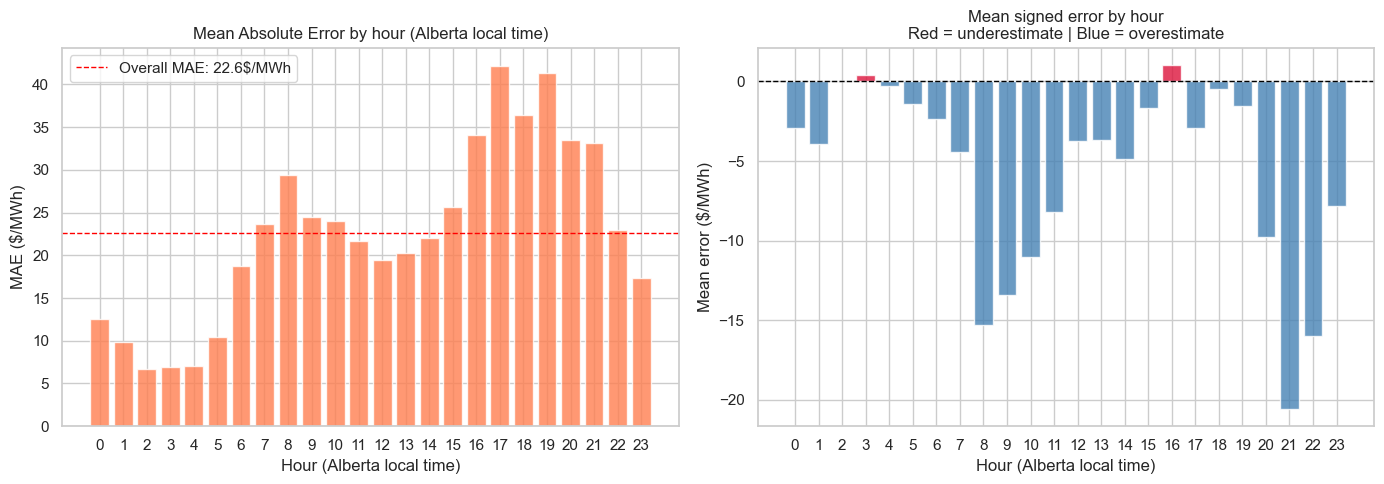

🔍 Top 3 hours with highest MAE :
hour_local
17    42.170238
19    41.310361
18    36.375517
Name: forecast_error, dtype: float64


In [82]:
# 📊 Q7 — At which hours does the AESO make the biggest mistakes ?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📈 Mean absolute error by hour (local time)
hourly_mae = df_clean.groupby("hour_local")["forecast_error"].apply(
    lambda x: x.abs().mean()
)

# 📈 Mean error by hour (signed — positive = underestimate)
hourly_mean_error = df_clean.groupby("hour_local")["forecast_error"].mean()

# Bar chart — MAE by hour
axes[0].bar(hourly_mae.index, hourly_mae.values, color="coral", alpha=0.8)
axes[0].set_title("Mean Absolute Error by hour (Alberta local time)")
axes[0].set_xlabel("Hour (Alberta local time)")
axes[0].set_ylabel("MAE ($/MWh)")
axes[0].set_xticks(range(0, 24))
axes[0].axhline(y=hourly_mae.mean(), color="red", linestyle="--",
                linewidth=1, label=f"Overall MAE: {hourly_mae.mean():.1f}$/MWh")
axes[0].legend()

# Bar chart — signed error by hour
colors = ["crimson" if x > 0 else "steelblue" for x in hourly_mean_error.values]
axes[1].bar(hourly_mean_error.index, hourly_mean_error.values, color=colors, alpha=0.8)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Mean signed error by hour\nRed = underestimate | Blue = overestimate")
axes[1].set_xlabel("Hour (Alberta local time)")
axes[1].set_ylabel("Mean error ($/MWh)")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print("🔍 Top 3 hours with highest MAE :")
print(hourly_mae.nlargest(3))

### Finding — AESO error by hour

- AESO is most accurate at night (1h-5h) — MAE ~6-10$/MWh
- AESO makes biggest mistakes during evening peak (17h-19h) — MAE ~40$/MWh
- AESO has a systematic bias — it overestimates almost every hour of the day
- The evening peak (17h-19h) is our biggest opportunity to beat the AESO

Key ML insight :
→ Hour of day must be a feature — the error pattern is strongly time-dependent.
→ Our model must be especially good between 16h and 20h local time.

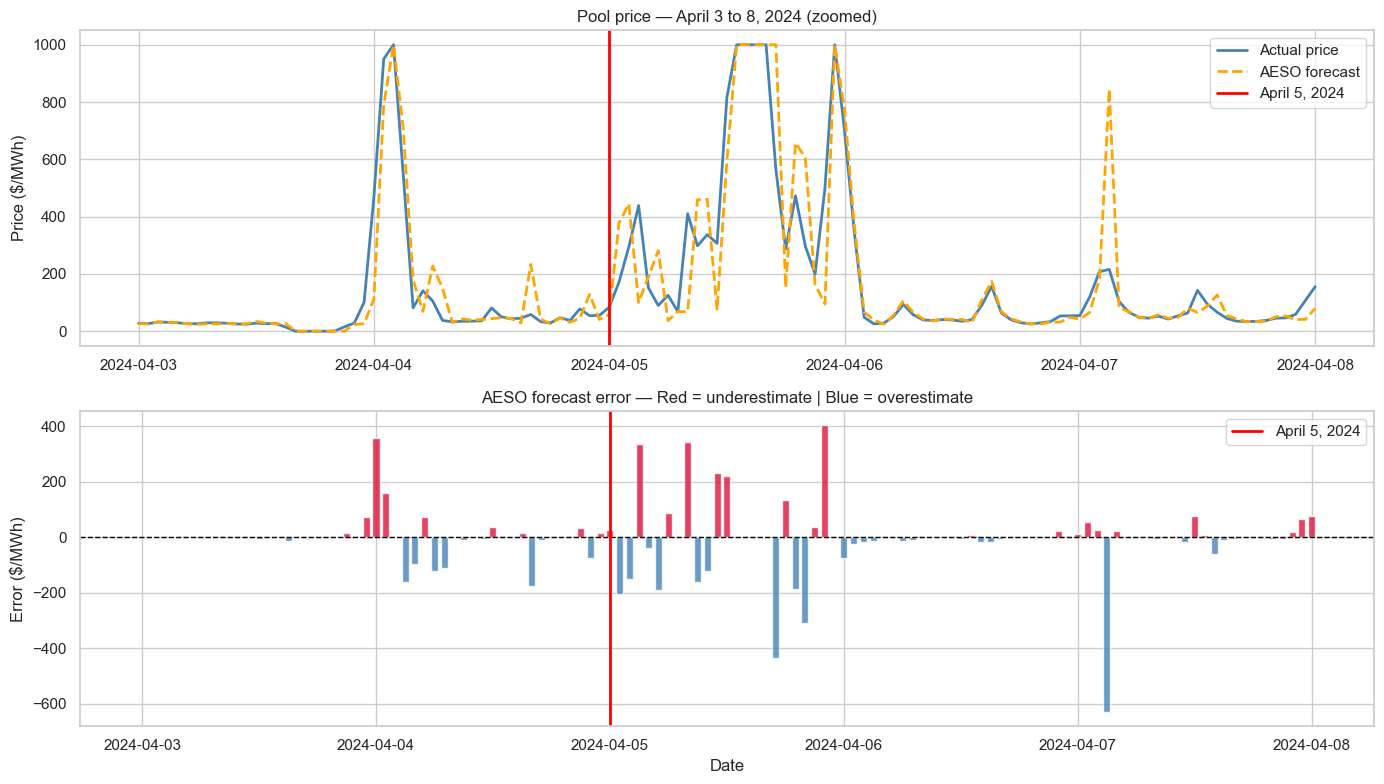

📊 April 5 — max price    : 999.99 $/MWh
📊 April 5 — max forecast : 999.99 $/MWh
📊 April 5 — max error    : 403.26 $/MWh
📊 April 5 — min error    : -436.15 $/MWh


In [85]:
# 📊 Q8 — April 5, 2024 — zoomed view
april5_window = df_clean[
    (df_clean.index >= "2024-04-03") &
    (df_clean.index <= "2024-04-08")
]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 📈 Top — Price zoom
axes[0].plot(april5_window.index, april5_window["price_actual"],
             color="steelblue", linewidth=2, label="Actual price")
axes[0].plot(april5_window.index, april5_window["price_forecast"],
             color="orange", linewidth=2, linestyle="--", label="AESO forecast")
axes[0].axvline(pd.Timestamp("2024-04-05", tz="UTC"),
                color="red", linewidth=2, linestyle="-", label="April 5, 2024")
axes[0].set_title("Pool price — April 3 to 8, 2024 (zoomed)")
axes[0].set_ylabel("Price ($/MWh)")
axes[0].legend()

# 📈 Bottom — Error zoom
axes[1].bar(april5_window.index,
            april5_window["forecast_error"],
            color=["crimson" if x > 0 else "steelblue"
                   for x in april5_window["forecast_error"]],
            width=0.03, alpha=0.8)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(pd.Timestamp("2024-04-05", tz="UTC"),
                color="red", linewidth=2, linestyle="-", label="April 5, 2024")
axes[1].set_title("AESO forecast error — Red = underestimate | Blue = overestimate")
axes[1].set_ylabel("Error ($/MWh)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

# 📊 Stats
april5 = df_clean[
    (df_clean.index >= "2024-04-05") &
    (df_clean.index < "2024-04-06")
]
print(f"📊 April 5 — max price    : {april5['price_actual'].max():.2f} $/MWh")
print(f"📊 April 5 — max forecast : {april5['price_forecast'].max():.2f} $/MWh")
print(f"📊 April 5 — max error    : {april5['forecast_error'].max():.2f} $/MWh")
print(f"📊 April 5 — min error    : {april5['forecast_error'].min():.2f} $/MWh")

### Finding — April 5, 2024

- Max price reached : 999.99$/MWh  legal market cap hit
- Max AESO underestimate : +403$/MWh — missed a real spike
- Max AESO overestimate  : -436$/MWh — predicted a spike that never came
- April 7 : AESO predicted 830$/MWh — actual was 220$/MWh (-630$ error)

The AESO saw the tension but could not predict the exact timing of spikes.
This is our opportunity — better spike timing prediction.

## Section 3 — Bivariate Analysis

Two variables at a time.

Goal: understand the relationships between variables.


Questions:

9. Demand vs Price — is the correlation strong ?
10. AESO forecast vs Actual price — how aligned are they ?
11. Hour of day vs AESO error — when does AESO fail the most ?

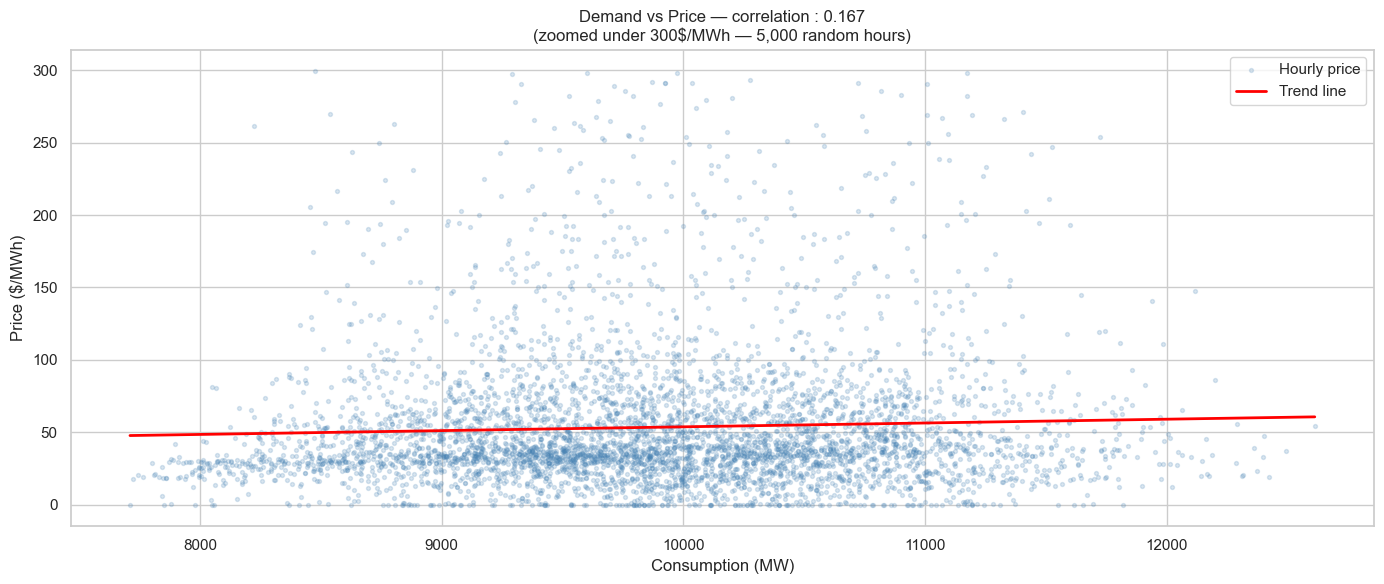

In [87]:
# 📊 Q9 — Demand vs Price — with trend line
fig, ax = plt.subplots(figsize=(14, 6))

# 🔵 Scatter — zoomed under 300$/MWh for readability
sample = df_clean[["consumption_actual", "price_actual"]].dropna()
sample_zoom = sample[sample["price_actual"] < 300].sample(5000, random_state=42)

ax.scatter(sample_zoom["consumption_actual"], sample_zoom["price_actual"],
           alpha=0.2, color="steelblue", s=8, label="Hourly price")

# 📈 Trend line
z = np.polyfit(sample_zoom["consumption_actual"], sample_zoom["price_actual"], 1)
p = np.poly1d(z)
x_line = np.linspace(sample_zoom["consumption_actual"].min(),
                     sample_zoom["consumption_actual"].max(), 100)
ax.plot(x_line, p(x_line), color="red", linewidth=2, label="Trend line")

# 📊 Correlation
corr = sample["consumption_actual"].corr(sample["price_actual"])
ax.set_title(f"Demand vs Price — correlation : {corr:.3f}\n(zoomed under 300$/MWh — 5,000 random hours)")
ax.set_xlabel("Consumption (MW)")
ax.set_ylabel("Price ($/MWh)")
ax.legend()

plt.tight_layout()
plt.show()

### Finding — Demand vs Price

Correlation = 0.167 — weak positive relationship.
Demand alone does not explain price.
Other factors matter more : time of day, season, generation capacity, imports/exports.

Key ML insight :
→ Consumption is a useful feature but not sufficient alone.
→ We need multiple features to predict price accurately.

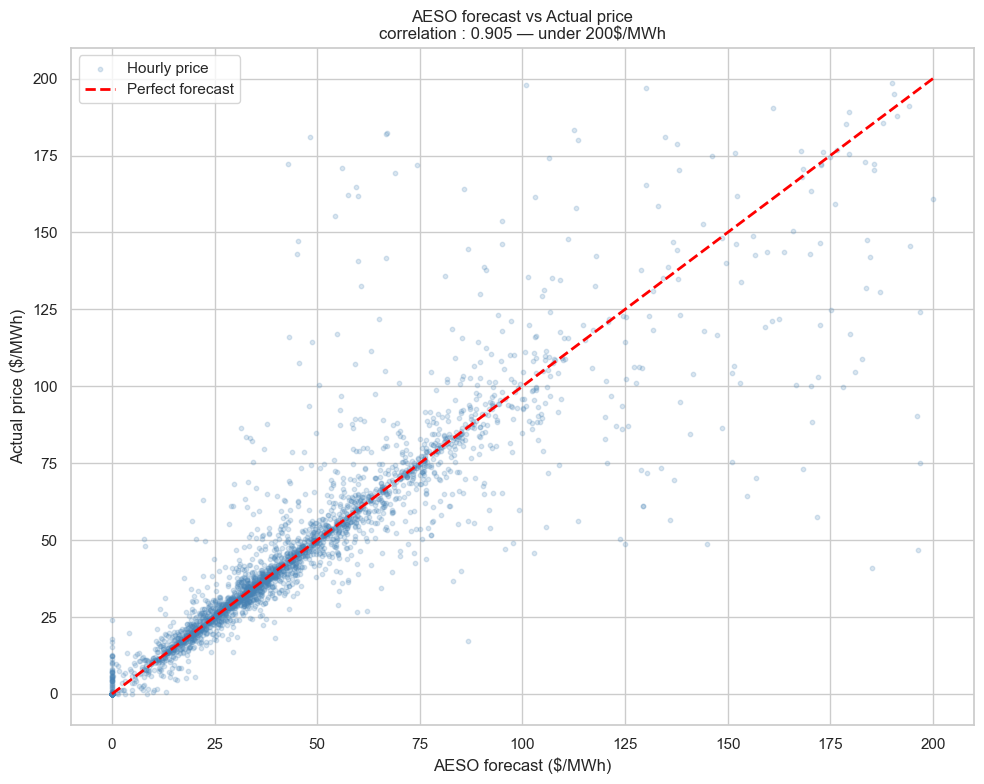

📊 Correlation forecast vs actual : 0.905


In [91]:
# 📊 Q10 — AESO forecast vs Actual price — simple and readable
fig, ax = plt.subplots(figsize=(10, 8))

# 🔵 Normal hours only — under 200$/MWh
sample = df_clean[
    (df_clean["price_actual"] < 200) &
    (df_clean["price_forecast"] < 200)
][["price_forecast", "price_actual"]].dropna().sample(3000, random_state=42)

ax.scatter(sample["price_forecast"], sample["price_actual"],
           alpha=0.2, color="steelblue", s=10, label="Hourly price")

# 📈 Perfect forecast diagonal
ax.plot([0, 200], [0, 200], color="red", linewidth=2,
        linestyle="--", label="Perfect forecast")

# 📊 Correlation
corr = df_clean[["price_forecast", "price_actual"]].dropna().corr()
corr_val = corr.loc["price_forecast", "price_actual"]

ax.set_title(f"AESO forecast vs Actual price\ncorrelation : {corr_val:.3f} — under 200$/MWh")
ax.set_xlabel("AESO forecast ($/MWh)")
ax.set_ylabel("Actual price ($/MWh)")
ax.legend()

plt.tight_layout()
plt.show()


# 📊 Correlation
corr = df_clean[["price_forecast", "price_actual"]].dropna().corr()
print(f"📊 Correlation forecast vs actual : {corr.loc['price_forecast', 'price_actual']:.3f}")

### Finding — AESO forecast vs Actual price

Correlation = 0.905 — very strong on normal hours (under 200$/MWh).
AESO is excellent when prices are stable and predictable.
But above 100$/MWh — points deviate from the diagonal.
AESO tends to overestimate on elevated prices.

Key ML insight :
→ AESO forecast is our strongest single feature — correlation 0.905.
→ Our model must improve on the hours where AESO deviates from the diagonal.
→ Focus: hours above 100$/MWh.

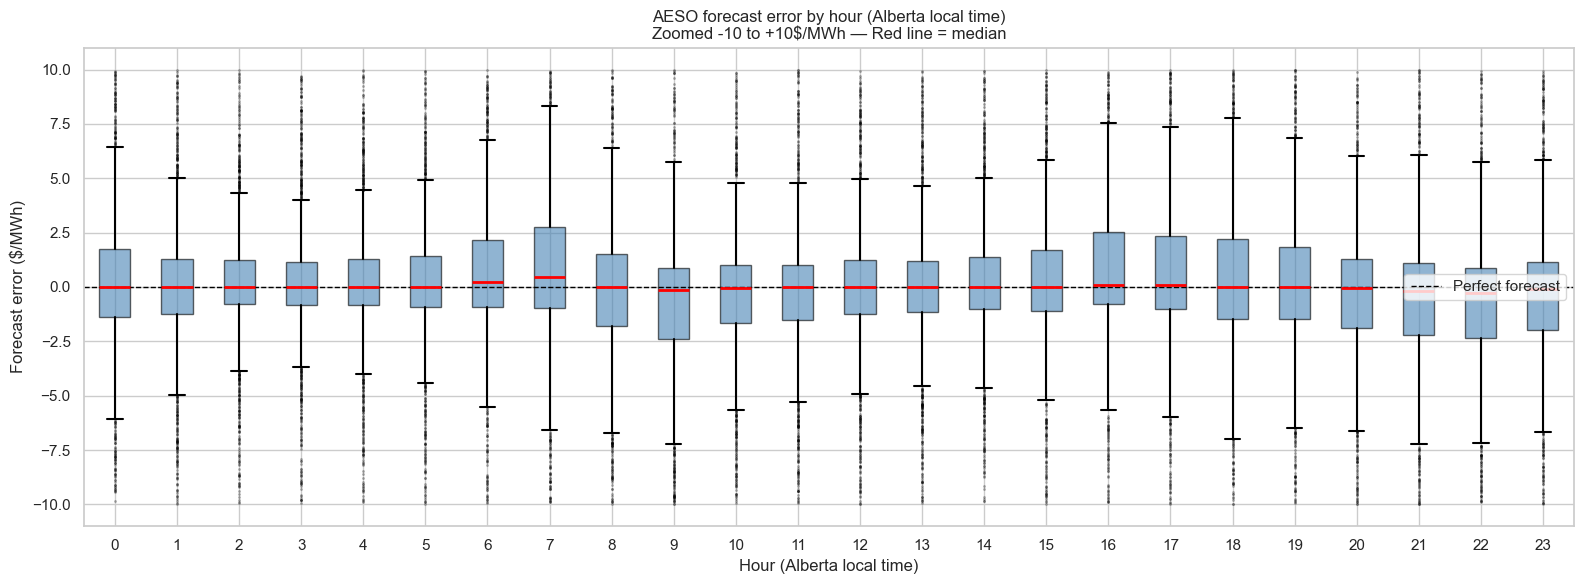

In [96]:
# 📊 Q11 — AESO error by hour — zoomed between -15 and +15
fig, ax = plt.subplots(figsize=(16, 6))

df_plot = df_clean[df_clean["forecast_error"].between(-10, 10)].copy()

hour_groups = [df_plot[df_plot["hour_local"] == h]["forecast_error"].values
               for h in range(24)]

ax.boxplot(hour_groups,
           positions=range(24),
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           medianprops=dict(color="red", linewidth=2),
           flierprops=dict(marker=".", markersize=2, alpha=0.3),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5))

ax.axhline(y=0, color="black", linestyle="--", linewidth=1, label="Perfect forecast")
ax.set_title("AESO forecast error by hour (Alberta local time)\nZoomed -10 to +10$/MWh — Red line = median")
ax.set_xlabel("Hour (Alberta local time)")
ax.set_ylabel("Forecast error ($/MWh)")
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.show()

### Finding — AESO error by hour

- Night (1h-5h)    : narrow boxes, median near 0 — AESO very accurate
- Morning (6h-8h)  : boxes widen — market becomes unpredictable
- Evening (16h-20h): boxes wider AND shifted above 0 — systematic underestimate
- Late night (21h-23h): median below 0 — AESO overestimates

Key ML insight :
→ Evening peak (16h-20h) is where AESO has a systematic bias.
→ Our model must correct this bias to beat the AESO baseline.

## Section 4 — Data Cleaning

Based on what we found in Sections 2 and 3.

Issues to fix:
1. Future hours (price = NULL) → already dropped in df_clean
2. price = 999.99 (market cap) → keep — real spikes
3. No other cleaning needed — data is surprisingly clean

What we keep :
- All 54,562 rows in df_clean
- All columns as-is

In [100]:
# 🧹 Section 4 — NULL analysis and cleaning decisions
print("❓ NULL analysis :")

null_summary = pd.DataFrame({
    "null_count" : df_clean.isnull().sum(),
    "null_pct"   : (df_clean.isnull().sum() / len(df_clean) * 100).round(1),
    "reason"     : [
        "—",                        # price_actual
        "—",                        # price_forecast
        "—",                        # consumption_actual
        "API only — not in CSV",    # consumption_forecast
        "CSV only — not in API",    # total_generation_mw
        "CSV only — not in API",    # export_to_bc
        "CSV only — not in API",    # export_to_mt
        "CSV only — not in API",    # export_to_sk
        "CSV only — not in API",    # import_from_bc
        "CSV only — not in API",    # import_from_mt
        "CSV only — not in API",    # import_from_sk
        "—",                        # source
        "—",                        # hour_local
        "—",                        # month
        "—",                        # forecast_error
    ]
})

print(null_summary[null_summary["null_count"] > 0])
print("\n✅ Decision : keep all columns")
print("   → NULLs are structural — not data quality issues")
print("   → ML feature selection will handle this later")
print(f"\n✅ df_clean ready — {len(df_clean):,} rows")

❓ NULL analysis :
                      null_count  null_pct                 reason
consumption_forecast       48935      89.7  API only — not in CSV
total_generation_mw         5627      10.3  CSV only — not in API
export_to_bc                5627      10.3  CSV only — not in API
export_to_mt                5627      10.3  CSV only — not in API
export_to_sk                5627      10.3  CSV only — not in API
import_from_bc              5627      10.3  CSV only — not in API
import_from_mt              5627      10.3  CSV only — not in API
import_from_sk              5627      10.3  CSV only — not in API

✅ Decision : keep all columns
   → NULLs are structural — not data quality issues
   → ML feature selection will handle this later

✅ df_clean ready — 54,562 rows


## Section 5 — Data Ready for ML

Summary of what we have and what we learned.

### Dataset
- 54,562 hourly rows — 2020 to 2026
- 2 sources : CSV historical + API real-time
- 0 data quality issues

### Key features identified for ML
| Feature | Availability | Importance |
|---------|-------------|------------|
| price_forecast | Always | ⭐⭐⭐ strongest signal (corr 0.905) |
| hour_local | Always | ⭐⭐⭐ strong daily pattern |
| month | Always | ⭐⭐ seasonal pattern |
| consumption_actual | Always | ⭐ weak signal (corr 0.167) |
| total_generation_mw | CSV only | ⭐ to evaluate |
| consumption_forecast | API only | ⭐ to evaluate |

### Baseline to beat
- AESO MAE : 22.64 $/MWh
- AESO is worst between 16h and 20h local time
- AESO has systematic overestimate bias on extreme events

In [102]:
# ✅ Section 5 — Final dataset summary
print("✅ Final dataset ready for ML")
print(f"   Rows         : {len(df_clean):,}")
print(f"   Date range   : {df_clean.index.min()} → {df_clean.index.max()}")
print(f"\n🏆 Baseline to beat :")
print(f"   AESO MAE     : {df_clean['forecast_error'].abs().mean():.2f} $/MWh")
print(f"   AESO worst   : hours 16h → 20h Alberta local time")
print(f"\n🎯 Our target  : MAE < {df_clean['forecast_error'].abs().mean():.2f} $/MWh")
print(f"                  especially on spikes above 300$/MWh")

✅ Final dataset ready for ML
   Rows         : 54,562
   Date range   : 2020-01-01 07:00:00+00:00 → 2026-03-23 16:00:00+00:00

🏆 Baseline to beat :
   AESO MAE     : 22.64 $/MWh
   AESO worst   : hours 16h → 20h Alberta local time

🎯 Our target  : MAE < 22.64 $/MWh
                  especially on spikes above 300$/MWh
